# Chapter 37 — Training a Tiny Model With Homemade Autograd

## Learning goals

Chapter 36 built a scalar automatic-differentiation engine called `TrackedNumber`.

This chapter uses that engine to train a two-parameter line model on several examples.

By the end of this chapter, you should be able to:

1. Use tracked scalar parameters in a training loop.
2. Build a fresh forward graph for several examples.
3. Compute average loss as one tracked scalar.
4. Clear parameter gradients before a backward pass.
5. Run backward and update raw parameter data.
6. Explain leaf-gradient accumulation across backward calls.
7. Distinguish useful accumulation inside one graph from stale accumulation across steps.
8. Compare homemade-autograd gradients with manual dataset gradients.
9. Store graph-free training history and plot the loss curve.
10. Recognize the training-loop pattern later used by PyTorch.

## The training problem

We train the line model:

```python
prediction = weight * input_number + bias
```

on:

```python
inputs = [1, 2, 3]
targets = [3, 5, 7]
```

The examples follow `target = 2 × input + 1`, so the exact line has weight `2` and bias `1`.

We start both parameters at zero and let gradient descent improve them.

## The training loop

Each full-batch training step follows this order:

1. Build a fresh forward graph and compute average loss.
2. Clear gradients left on the parameter leaves.
3. Run the loss backward pass.
4. Update the raw parameter data.

The graph describes the current parameter values, so a new forward pass is required after every update.

## Terms used in this chapter

- A **parameter leaf** is a tracked value updated by training.
- A **full batch** uses every training example in one step.
- A **forward graph** records the operations that produced the current loss.
- A **backward pass** computes loss derivatives for graph values.
- **Leaf-gradient accumulation** means new backward contributions add to gradients already stored on leaves.
- **Clearing gradients** resets parameter gradients before computing a new step.
- A **raw-data update** changes parameter data without recording the update in the graph.

Accumulation through multiple paths in one graph is required.

Accumulation of stale parameter gradients across independent training steps is usually a bug.

## Use a PyTorch-like leaf accumulation policy

Chapter 36 reset every reachable gradient at the beginning of `backward()`.

For training practice, this version resets internal graph nodes but preserves leaf gradients.

That makes repeated backward calls accumulate on parameters until we explicitly clear them, which matches the behavior we will later see in PyTorch.

## Define the scalar autograd engine

The arithmetic rules are unchanged from Chapter 36.

Only the gradient-reset policy inside `backward()` has changed.

In [1]:
from collections.abc import Callable


class TrackedNumber:
    def __init__(
        self,
        data: float,
        previous_values: tuple["TrackedNumber", ...] = (),
        operation: str = "",
        label: str = "",
    ) -> None:
        self.data = float(data)
        self.gradient = 0.0
        self._previous_values = previous_values
        self._operation = operation
        self.label = label
        self._backward: Callable[[], None] = lambda: None

    def __repr__(self) -> str:
        return (
            f"TrackedNumber(data={self.data}, "
            f"gradient={self.gradient}, "
            f"label={self.label!r})"
        )

    @staticmethod
    def _ensure_tracked(value: object) -> "TrackedNumber":
        if isinstance(value, TrackedNumber):
            return value

        if isinstance(value, int | float):
            return TrackedNumber(float(value))

        raise TypeError(
            f"Expected a TrackedNumber, int, or float. Received {type(value).__name__}."
        )

    def __add__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        output = TrackedNumber(
            self.data + other_value.data,
            previous_values=(self, other_value),
            operation="+",
        )

        def _backward() -> None:
            self.gradient += output.gradient
            other_value.gradient += output.gradient

        output._backward = _backward
        return output

    def __radd__(self, other: object) -> "TrackedNumber":
        return self + other

    def __sub__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        output = TrackedNumber(
            self.data - other_value.data,
            previous_values=(self, other_value),
            operation="-",
        )

        def _backward() -> None:
            self.gradient += output.gradient
            other_value.gradient -= output.gradient

        output._backward = _backward
        return output

    def __rsub__(self, other: object) -> "TrackedNumber":
        return self._ensure_tracked(other) - self

    def __mul__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        left_data = self.data
        right_data = other_value.data
        output = TrackedNumber(
            left_data * right_data,
            previous_values=(self, other_value),
            operation="*",
        )

        def _backward() -> None:
            self.gradient += right_data * output.gradient
            other_value.gradient += left_data * output.gradient

        output._backward = _backward
        return output

    def __rmul__(self, other: object) -> "TrackedNumber":
        return self * other

    def __truediv__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        numerator_data = self.data
        denominator_data = other_value.data

        if denominator_data == 0:
            raise ZeroDivisionError("Cannot divide by zero.")

        output = TrackedNumber(
            numerator_data / denominator_data,
            previous_values=(self, other_value),
            operation="/",
        )

        def _backward() -> None:
            self.gradient += output.gradient / denominator_data
            other_value.gradient -= (
                numerator_data * output.gradient / denominator_data**2
            )

        output._backward = _backward
        return output

    def __rtruediv__(self, other: object) -> "TrackedNumber":
        return self._ensure_tracked(other) / self

    def __pow__(self, exponent: int | float) -> "TrackedNumber":
        if not isinstance(exponent, int | float):
            raise TypeError("Only int and float constant exponents are supported.")

        base_data = self.data
        output_data = base_data**exponent

        if isinstance(output_data, complex):
            raise ValueError("This engine supports real-valued powers only.")

        output = TrackedNumber(
            output_data,
            previous_values=(self,),
            operation=f"**{exponent}",
        )

        def _backward() -> None:
            self.gradient += exponent * base_data ** (exponent - 1) * output.gradient

        output._backward = _backward
        return output

    def __neg__(self) -> "TrackedNumber":
        return self * -1.0

    def _topological_order(self) -> list["TrackedNumber"]:
        ordered_values = []
        visited_values = set()

        def visit(current_value: "TrackedNumber") -> None:
            if current_value in visited_values:
                return

            visited_values.add(current_value)

            for previous_value in current_value._previous_values:
                visit(previous_value)

            ordered_values.append(current_value)

        visit(self)
        return ordered_values

    def backward(self) -> None:
        ordered_values = self._topological_order()

        # Internal gradients belong only to this graph traversal.
        for value in ordered_values:
            if value._previous_values:
                value.gradient = 0.0

        self.gradient = 1.0

        for value in reversed(ordered_values):
            value._backward()

Leaf nodes have no parents, so their gradients survive until explicitly cleared.

Internal nodes are reset before traversal so stale intermediate gradients do not corrupt repeated backward calls.

## Verify the engine and its accumulation policy

Run the shared-node example twice.

The first pass produces gradient `3` on each leaf, and the second pass adds the same contributions again.

In [2]:
first_number = TrackedNumber(2.0, label="first_number")
second_number = TrackedNumber(3.0, label="second_number")
result = first_number * second_number + second_number

result.backward()
print("After first backward:")
print("first gradient:", first_number.gradient)
print("second gradient:", second_number.gradient)

result.backward()
print()
print("After second backward without clearing:")
print("first gradient:", first_number.gradient)
print("second gradient:", second_number.gradient)

assert first_number.gradient == 6.0
assert second_number.gradient == 6.0

After first backward:
first gradient: 3.0
second gradient: 3.0

After second backward without clearing:
first gradient: 6.0
second gradient: 6.0


The doubled leaf gradients demonstrate accumulation across backward calls.

The `+` rules also accumulated both paths to `second_number` correctly within each individual pass.

## Define gradient clearing

Training code usually clears only the parameter leaves it plans to update.

In [3]:
def clear_gradients(parameters: list[TrackedNumber]) -> None:
    for parameter in parameters:
        parameter.gradient = 0.0


clear_gradients([first_number, second_number])

print("First gradient after clearing:", first_number.gradient)
print("Second gradient after clearing:", second_number.gradient)

First gradient after clearing: 0.0
Second gradient after clearing: 0.0


Clearing gradients does not change parameter data or graph structure.

## Create and inspect the dataset

Use floating-point values so their role as numerical training data is explicit.

In [4]:
inputs = [1.0, 2.0, 3.0]
targets = [3.0, 5.0, 7.0]

print("input | target")
print("-" * 16)

for input_number, target_number in zip(inputs, targets, strict=True):
    print(f"{input_number:>5.1f} | {target_number:>6.1f}")

input | target
----------------
  1.0 |    3.0
  2.0 |    5.0
  3.0 |    7.0


Several distinct inputs make weight and bias identifiable for this exact line, unlike the one-example graph in Chapter 35.

## Define prediction and one-example loss

Ordinary input and target numbers become constant tracked leaves when they enter arithmetic.

In [5]:
def predict(
    input_number: float,
    weight: TrackedNumber,
    bias: TrackedNumber,
) -> TrackedNumber:
    return weight * input_number + bias


def squared_error_loss(
    prediction: TrackedNumber,
    target_number: float,
) -> TrackedNumber:
    return (prediction - target_number) ** 2


test_weight = TrackedNumber(0.0, label="weight")
test_bias = TrackedNumber(0.0, label="bias")
test_prediction = predict(1.0, test_weight, test_bias)
test_loss = squared_error_loss(test_prediction, 3.0)

print("Prediction:", test_prediction)
print("Squared error loss:", test_loss)

Prediction: TrackedNumber(data=0.0, gradient=0.0, label='')
Squared error loss: TrackedNumber(data=9.0, gradient=0.0, label='')


At zero weight and bias, the first prediction is zero and its squared error loss is nine.

## Build average loss over the full batch

All example losses share the same weight and bias leaves.

Backward therefore accumulates every example's contribution into the two parameter gradients.

In [6]:
def validate_dataset(inputs: list[float], targets: list[float]) -> None:
    if len(inputs) != len(targets):
        raise ValueError("inputs and targets must have the same length.")

    if len(inputs) == 0:
        raise ValueError("inputs and targets must not be empty.")


def average_loss_over_dataset(
    inputs: list[float],
    targets: list[float],
    weight: TrackedNumber,
    bias: TrackedNumber,
) -> TrackedNumber:
    validate_dataset(inputs, targets)
    total_loss = TrackedNumber(0.0)

    for input_number, target_number in zip(inputs, targets, strict=True):
        prediction = predict(input_number, weight, bias)
        total_loss = total_loss + squared_error_loss(
            prediction,
            target_number,
        )

    average_loss = total_loss / len(inputs)
    average_loss.label = "average_loss"
    return average_loss

Compute the initial average loss, clear parameter gradients, and run backward.

In [7]:
weight = TrackedNumber(0.0, label="weight")
bias = TrackedNumber(0.0, label="bias")

average_loss = average_loss_over_dataset(
    inputs,
    targets,
    weight,
    bias,
)
clear_gradients([weight, bias])
average_loss.backward()

print("Average loss:", average_loss.data)
print("Weight gradient:", weight.gradient)
print("Bias gradient:", bias.gradient)

Average loss: 27.666666666666668
Weight gradient: -22.666666666666664
Bias gradient: -10.0


These are derivatives of the average loss, because division by the number of examples is part of the tracked graph.

## Compare with manual dataset gradients

The manual formulas from Chapter 34 provide an independent check.

In [8]:
def compute_manual_gradients(
    inputs: list[float],
    targets: list[float],
    weight_data: float,
    bias_data: float,
) -> tuple[float, float]:
    validate_dataset(inputs, targets)
    weight_gradient_total = 0.0
    bias_gradient_total = 0.0

    for input_number, target_number in zip(inputs, targets, strict=True):
        prediction = weight_data * input_number + bias_data
        error = prediction - target_number
        weight_gradient_total += 2 * error * input_number
        bias_gradient_total += 2 * error

    number_of_examples = len(inputs)
    return (
        weight_gradient_total / number_of_examples,
        bias_gradient_total / number_of_examples,
    )


manual_weight_gradient, manual_bias_gradient = compute_manual_gradients(
    inputs,
    targets,
    weight.data,
    bias.data,
)

print("Autograd weight gradient:", weight.gradient)
print("Manual weight gradient:", manual_weight_gradient)
print("Autograd bias gradient:", bias.gradient)
print("Manual bias gradient:", manual_bias_gradient)

assert abs(weight.gradient - manual_weight_gradient) < 1e-12
assert abs(bias.gradient - manual_bias_gradient) < 1e-12

Autograd weight gradient: -22.666666666666664
Manual weight gradient: -22.666666666666668
Autograd bias gradient: -10.0
Manual bias gradient: -10.0


Homemade autograd reproduces the same chain-rule result without a dataset-specific backward formula.

## Perform one complete training step

Update raw `.data` so the optimizer operation is not added to the forward graph.

The old loss keeps its old forward data; a new loss must be built after the update.

In [9]:
learning_rate = 0.05

old_weight_data = weight.data
old_bias_data = bias.data
old_loss_data = average_loss.data

weight.data -= learning_rate * weight.gradient
bias.data -= learning_rate * bias.gradient

new_loss = average_loss_over_dataset(
    inputs,
    targets,
    weight,
    bias,
)

print("Old parameters:", (old_weight_data, old_bias_data))
print("New parameters:", (weight.data, bias.data))
print("Old loss object still stores:", average_loss.data)
print("Fresh loss after update:", new_loss.data)

assert average_loss.data == old_loss_data
assert new_loss.data < old_loss_data

Old parameters: (0.0, 0.0)
New parameters: (1.1333333333333333, 0.5)
Old loss object still stores: 27.666666666666668
Fresh loss after update: 5.488518518518519


The fresh forward pass sees the updated data and produces a lower loss.

## Package one training run

Store plain floats in history rather than tracked loss objects.

Keeping old tracked results would retain their full computation graphs and waste memory.

In [10]:
def train_tiny_model(
    inputs: list[float],
    targets: list[float],
    initial_weight: float,
    initial_bias: float,
    learning_rate: float,
    number_of_steps: int,
) -> tuple[list[dict[str, float]], TrackedNumber, TrackedNumber]:
    validate_dataset(inputs, targets)

    if learning_rate <= 0:
        raise ValueError("learning_rate must be positive.")

    if number_of_steps < 1:
        raise ValueError("number_of_steps must be at least 1.")

    weight = TrackedNumber(initial_weight, label="weight")
    bias = TrackedNumber(initial_bias, label="bias")
    history = []

    for step in range(number_of_steps):
        average_loss = average_loss_over_dataset(
            inputs,
            targets,
            weight,
            bias,
        )

        clear_gradients([weight, bias])
        average_loss.backward()

        updated_weight = weight.data - learning_rate * weight.gradient
        updated_bias = bias.data - learning_rate * bias.gradient

        history.append(
            {
                "step": step,
                "weight": weight.data,
                "bias": bias.data,
                "loss": average_loss.data,
                "weight_gradient": weight.gradient,
                "bias_gradient": bias.gradient,
                "updated_weight": updated_weight,
                "updated_bias": updated_bias,
            }
        )

        weight.data = updated_weight
        bias.data = updated_bias

    return history, weight, bias

Print every step of a short run so the forward, backward, and update values are visible.

In [11]:
short_history, _, _ = train_tiny_model(
    inputs,
    targets,
    initial_weight=0.0,
    initial_bias=0.0,
    learning_rate=0.05,
    number_of_steps=15,
)

print(
    "step | weight | bias | loss | "
    "weight grad | bias grad | updated weight | updated bias"
)
print("-" * 112)

for row in short_history:
    print(
        f"{int(row['step']):>4} | "
        f"{row['weight']:>8.5f} | "
        f"{row['bias']:>8.5f} | "
        f"{row['loss']:>10.6f} | "
        f"{row['weight_gradient']:>11.6f} | "
        f"{row['bias_gradient']:>9.6f} | "
        f"{row['updated_weight']:>14.6f} | "
        f"{row['updated_bias']:>12.6f}"
    )

step | weight | bias | loss | weight grad | bias grad | updated weight | updated bias
----------------------------------------------------------------------------------------------------------------
   0 |  0.00000 |  0.00000 |  27.666667 |  -22.666667 | -10.000000 |       1.133333 |     0.500000
   1 |  1.13333 |  0.50000 |   5.488519 |  -10.088889 | -4.466667 |       1.637778 |     0.723333
   2 |  1.63778 |  0.72333 |   1.089693 |   -4.487407 | -2.002222 |       1.862148 |     0.823444
   3 |  1.86215 |  0.82344 |   0.217207 |   -1.992840 | -0.904519 |       1.961790 |     0.868670
   4 |  1.96179 |  0.86867 |   0.044133 |   -0.881944 | -0.415499 |       2.005887 |     0.889445
   5 |  2.00589 |  0.88945 |   0.009781 |   -0.387270 | -0.197560 |       2.025251 |     0.899323
   6 |  2.02525 |  0.89932 |   0.002943 |   -0.167032 | -0.100350 |       2.033602 |     0.904341
   7 |  2.03360 |  0.90434 |   0.001562 |   -0.069014 | -0.056909 |       2.037053 |     0.907186
   8 |  2.03705 

The loss decreases and both parameters move toward the exact line.

## Train long enough to fit the dataset

Use the same stable learning rate for 500 steps.

In [12]:
training_history, trained_weight, trained_bias = train_tiny_model(
    inputs,
    targets,
    initial_weight=0.0,
    initial_bias=0.0,
    learning_rate=0.05,
    number_of_steps=500,
)

final_loss = average_loss_over_dataset(
    inputs,
    targets,
    trained_weight,
    trained_bias,
)

print("Final weight:", trained_weight.data)
print("Final bias:", trained_bias.data)
print("Final average loss:", final_loss.data)

assert abs(trained_weight.data - 2.0) < 0.001
assert abs(trained_bias.data - 1.0) < 0.003
assert final_loss.data < 1e-6

Final weight: 2.000104850952742
Final bias: 0.9997616491392355
Final average loss: 8.149910832601979e-09


The engine and gradient-descent loop recover a line very close to `2x + 1`.

## Plot loss and parameters

One figure shows optimization progress and parameter trajectories.

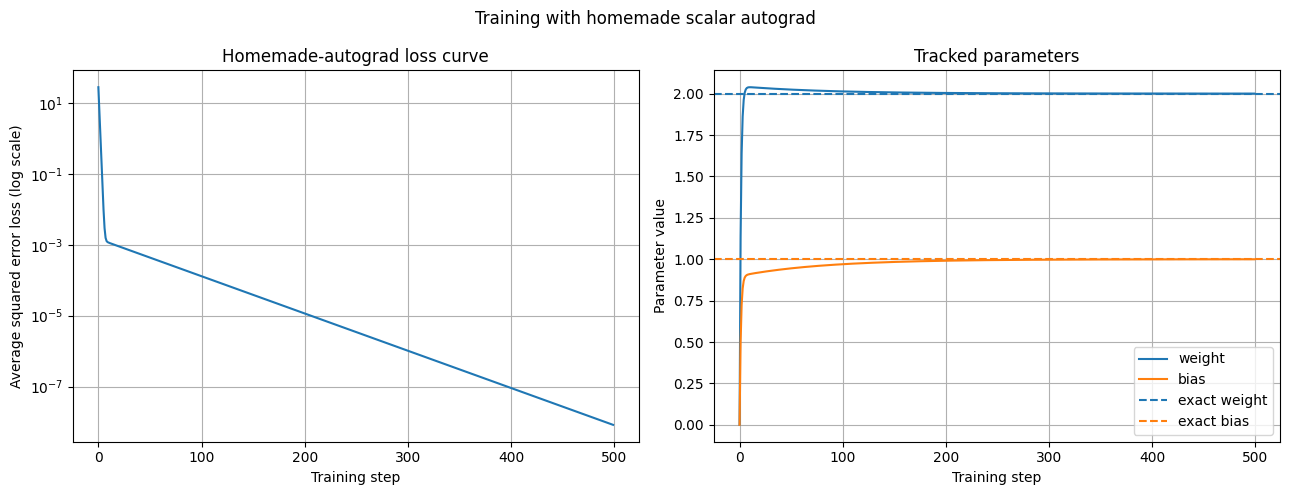

In [13]:
import matplotlib.pyplot as plt

steps = [int(row["step"]) for row in training_history]
losses = [row["loss"] for row in training_history]
weights = [row["weight"] for row in training_history]
biases = [row["bias"] for row in training_history]

figure, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(steps, losses)
axes[0].set_yscale("log")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Average squared error loss (log scale)")
axes[0].set_title("Homemade-autograd loss curve")
axes[0].grid(True)

axes[1].plot(steps, weights, label="weight")
axes[1].plot(steps, biases, label="bias")
axes[1].axhline(2.0, linestyle="--", color="tab:blue", label="exact weight")
axes[1].axhline(1.0, linestyle="--", color="tab:orange", label="exact bias")
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("Parameter value")
axes[1].set_title("Tracked parameters")
axes[1].legend()
axes[1].grid(True)

figure.suptitle("Training with homemade scalar autograd")
figure.tight_layout()
plt.show()

The falling loss confirms useful gradients, while the parameter panel shows the path toward the exact values.

## Plot the line before and after training

The learned parameters matter because of the predictions they produce.

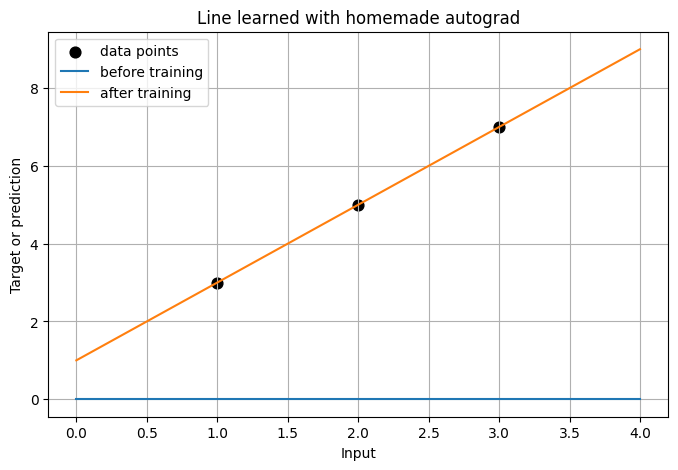

In [14]:
x_values = [step * 0.1 for step in range(41)]
initial_line = [0.0 for x_value in x_values]
trained_line = [
    trained_weight.data * x_value + trained_bias.data for x_value in x_values
]

plt.figure(figsize=(8, 5))
plt.scatter(inputs, targets, color="black", s=60, label="data points")
plt.plot(x_values, initial_line, label="before training")
plt.plot(x_values, trained_line, label="after training")
plt.xlabel("Input")
plt.ylabel("Target or prediction")
plt.title("Line learned with homemade autograd")
plt.legend()
plt.grid(True)
plt.show()

The initial line predicts zero everywhere, while the trained line passes almost exactly through the data.

## Demonstrate the stale-gradient bug

Build two fresh loss graphs at unchanged parameters and run backward twice without clearing the shared parameter leaves.

In [15]:
accumulating_weight = TrackedNumber(0.0, label="weight")
accumulating_bias = TrackedNumber(0.0, label="bias")

first_loss = average_loss_over_dataset(
    inputs,
    targets,
    accumulating_weight,
    accumulating_bias,
)
clear_gradients([accumulating_weight, accumulating_bias])
first_loss.backward()

first_weight_gradient = accumulating_weight.gradient
first_bias_gradient = accumulating_bias.gradient

second_loss = average_loss_over_dataset(
    inputs,
    targets,
    accumulating_weight,
    accumulating_bias,
)
second_loss.backward()

print("After one backward:")
print((first_weight_gradient, first_bias_gradient))
print("After a second backward without clearing:")
print((accumulating_weight.gradient, accumulating_bias.gradient))

assert accumulating_weight.gradient == 2 * first_weight_gradient
assert accumulating_bias.gradient == 2 * first_bias_gradient

After one backward:
(-22.666666666666664, -10.0)
After a second backward without clearing:
(-45.33333333333333, -20.0)


The second backward adds another copy of the same gradient because the parameters did not change.

Using the doubled stale gradient for one ordinary step would make the update twice as large as intended.

## Correct the bug by clearing

Reset the parameter leaves before the next backward pass.

In [16]:
third_loss = average_loss_over_dataset(
    inputs,
    targets,
    accumulating_weight,
    accumulating_bias,
)
clear_gradients([accumulating_weight, accumulating_bias])
third_loss.backward()

print("Weight gradient after clearing:", accumulating_weight.gradient)
print("Bias gradient after clearing:", accumulating_bias.gradient)

assert accumulating_weight.gradient == first_weight_gradient
assert accumulating_bias.gradient == first_bias_gradient

Weight gradient after clearing: -22.666666666666664
Bias gradient after clearing: -10.0


Clearing restores the gradient for one current loss computation.

## Within-graph accumulation remains necessary

If one leaf appears twice in one graph, both path contributions must still add.

In [17]:
shared_number = TrackedNumber(5.0, label="shared_number")
shared_result = shared_number + shared_number

clear_gradients([shared_number])
shared_result.backward()

print("d result / d shared_number:", shared_number.gradient)

assert shared_number.gradient == 2.0

d result / d shared_number: 2.0


The engine preserves this correct accumulation while training code clears only stale cross-step gradients.

## Autograd does not choose the learning rate

Automatic differentiation computes gradients but does not decide how aggressively to use them.

Compare a stable rate with an unstable large rate.

In [18]:
stable_history, _, _ = train_tiny_model(
    inputs,
    targets,
    initial_weight=0.0,
    initial_bias=0.0,
    learning_rate=0.05,
    number_of_steps=20,
)
unstable_history, _, _ = train_tiny_model(
    inputs,
    targets,
    initial_weight=0.0,
    initial_bias=0.0,
    learning_rate=0.5,
    number_of_steps=20,
)

print("Stable final displayed loss:", stable_history[-1]["loss"])
print("Unstable final displayed loss:", unstable_history[-1]["loss"])

assert stable_history[-1]["loss"] < stable_history[0]["loss"]
assert unstable_history[-1]["loss"] > unstable_history[0]["loss"]

Stable final displayed loss: 0.0009189341775488495
Unstable final displayed loss: 2.713681590617525e+26


Correct gradients can still produce divergent training when the update rule uses an unsafe learning rate.

## The PyTorch-shaped loop

Our homemade loop is:

```text
loss = forward pass
clear_gradients(parameters)
loss.backward()
update parameter data
```

The later PyTorch pattern will be:

```text
loss = forward pass
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

The tools differ, but the conceptual ordering is the same.

## A clean homemade-autograd pipeline

This final cell trains, evaluates, and verifies the complete result.

In [19]:
pipeline_history, pipeline_weight, pipeline_bias = train_tiny_model(
    inputs,
    targets,
    initial_weight=0.0,
    initial_bias=0.0,
    learning_rate=0.05,
    number_of_steps=500,
)

pipeline_loss = average_loss_over_dataset(
    inputs,
    targets,
    pipeline_weight,
    pipeline_bias,
)
pipeline_predictions = [
    predict(input_number, pipeline_weight, pipeline_bias).data
    for input_number in inputs
]

assert pipeline_history[-1]["loss"] < pipeline_history[0]["loss"]
assert abs(pipeline_weight.data - 2.0) < 0.001
assert abs(pipeline_bias.data - 1.0) < 0.003
assert pipeline_loss.data < 1e-6

print("Learned weight:", pipeline_weight.data)
print("Learned bias:", pipeline_bias.data)
print("Final predictions:", pipeline_predictions)
print("Final average loss:", pipeline_loss.data)
print("All homemade-autograd training checks passed.")

Learned weight: 2.000104850952742
Learned bias: 0.9997616491392355
Final predictions: [2.9998665000919775, 4.999971351044719, 7.000076201997461]
Final average loss: 8.149910832601979e-09
All homemade-autograd training checks passed.


## What not to do

- Do not let stale parameter gradients leak into an ordinary new training step.
- Do not clear internal path contributions during one backward traversal.
- Do not update parameters before backward computes their current gradients.
- Do not record parameter updates as differentiable forward operations in this tiny engine.
- Do not reuse an old loss after changing parameter data.
- Do not store old graph objects in long histories when plain scalar data is enough.
- Do not assume autograd selects a safe learning rate.

## Gotchas

- Parameter leaves are shared by every example in the full-batch graph.
- Backward sums all example and path contributions into those leaves.
- This chapter's engine preserves leaf gradients across backward calls.
- `clear_gradients` must run before each independent training backward pass.
- Internal graph gradients are reset by `backward()` to avoid stale intermediate values.
- Raw-data updates are followed by a fresh forward graph.
- History stores floats so completed graphs can be released.

## Takeaways

We trained `prediction = weight × input + bias` using our own scalar autograd engine.

Each step built average loss, cleared parameter gradients, ran backward, and updated raw data.

The engine automatically accumulated contributions from all examples and all graph paths.

Explicit clearing prevented old parameter gradients from contaminating the next step.

With a stable learning rate, the learned weight approached `2`, the bias approached `1`, and average loss approached zero.

This is the same conceptual training-loop structure we will use with tensor autograd.

## What comes next

The next chapter introduces PyTorch tensors and PyTorch autograd.

PyTorch will replace scalar `TrackedNumber` objects with efficient tensors while preserving the forward, clear, backward, and update pattern.